In [1]:
!  pip install matplotlib

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode, hmean, gmean, skew, kurtosis
c = "earthquake_dataset.csv"

df = pd.read_csv(c);

display(df)

,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449
...,...,...,...,...,...,...,...,...,...
16939,2015-03-19,10:05:59,163 km NW of Ternate,Indonesia,1.9433,126.4571,5.4,31.540,449
16940,2015-03-19,08:34:16,100 km NW of Talcahuano,Chile,-36.0228,-73.8197,5.2,3.860,416
16941,2015-03-19,03:49:23,South Sandwich Islands region,South Sandwich Islands region,-55.3910,-28.3497,5.0,28.900,385
16942,2015-03-19,03:15:22,218 km ENE of Petropavlovsk-Kamchatsky,Russia,53.5155,161.8237,5.2,13.700,416


Análise da Coluna: Earthquake Magnitude
Coeficiente de Assimetria: 2.14
Coeficiente de Curtose: 6.26
Desvio Padrão: 0.40
Variância: 0.16
Coeficiente de Variação (CV): 7.58%
Intervalo Interquartil (IQR): 0.40000000000000036
Desvio Absoluto Mediano (MAD): 0.20000000000000018
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 5.333485009442871
Mediana: 5.2
Moda: 5.0
Média Harmônica: 5.306723941551641
Média Geométrica: 5.319517308721593


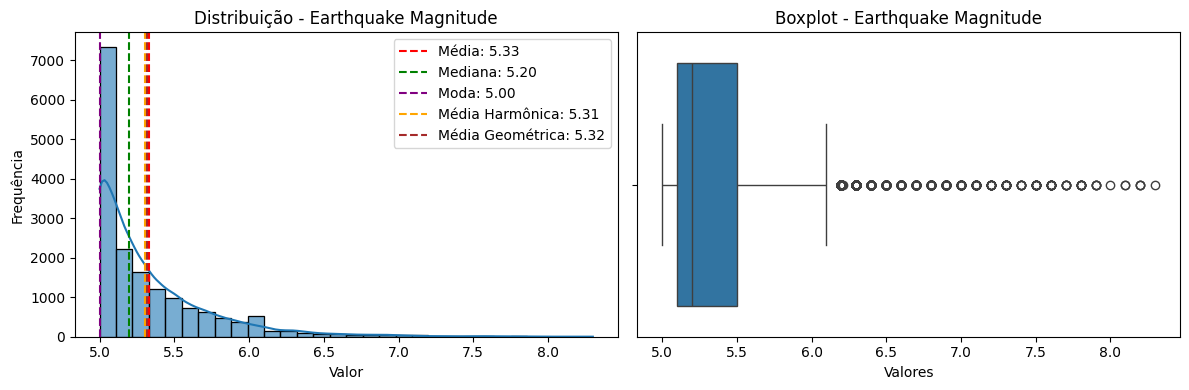

Análise da Coluna: Depth (km)
Coeficiente de Assimetria: 3.87
Coeficiente de Curtose: 15.63
Desvio Padrão: 104.09
Variância: 10834.92
Coeficiente de Variação (CV): 195.65%
Intervalo Interquartil (IQR): 35.55775
Desvio Absoluto Mediano (MAD): 3.385
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 53.202267457956616
Mediana: 11.8925
Moda: 10.0


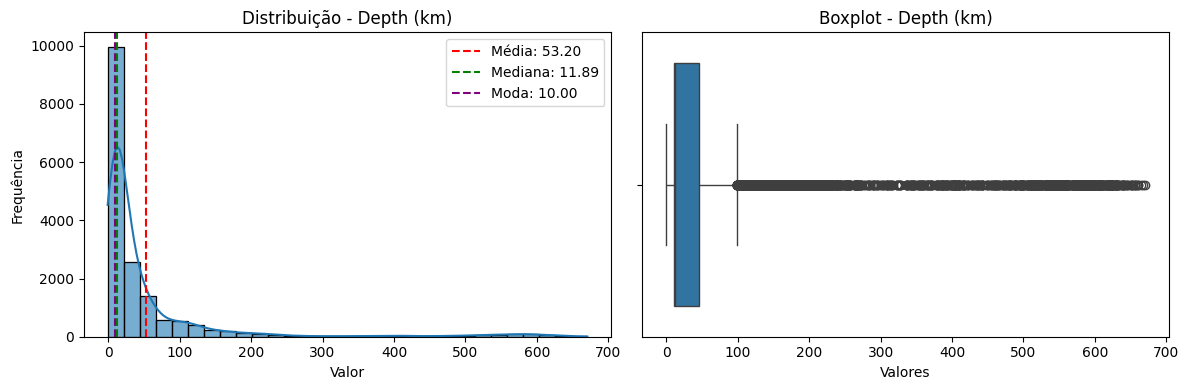

Análise da Coluna: Impact Score
Coeficiente de Assimetria: 7.69
Coeficiente de Curtose: 91.82
Desvio Padrão: 137.23
Variância: 18832.62
Coeficiente de Variação (CV): 30.15%
Intervalo Interquartil (IQR): 65.0
Desvio Absoluto Mediano (MAD): 31.0
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 455.2163597733711
Mediana: 416.0
Moda: 385
Média Harmônica: 437.5522853638125
Média Geométrica: 444.41433593613795


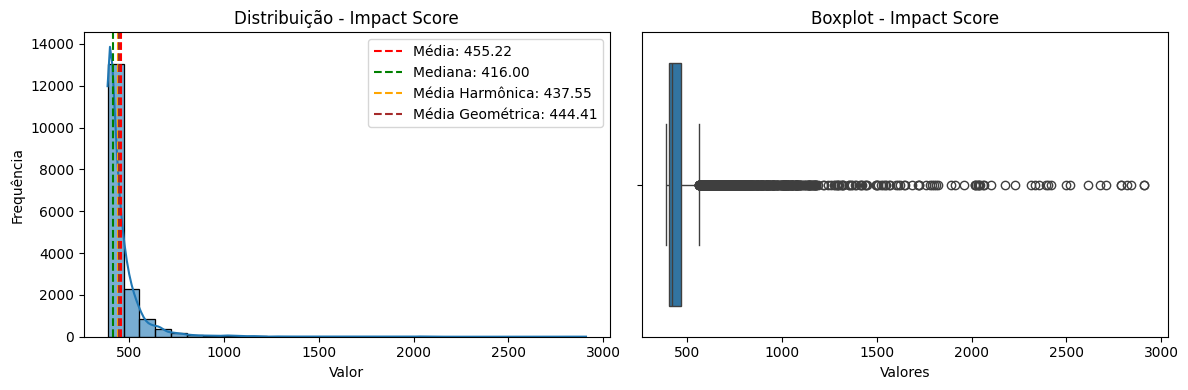

In [3]:
def calculate_centrality_measures(data, measures):
    results = {}
    data = np.array(data)

    if 'Média' in measures:
        results['Média'] = np.mean(data)

    if 'Mediana' in measures:
        results['Mediana'] = np.median(data)

    if 'Moda' in measures:
        rounded_data = np.round(data)
        mode_result = mode(rounded_data, keepdims=True)
        if len(mode_result.count) > 0 and mode_result.count[0] > 1:
            results['Moda'] = mode_result.mode[0]
        else:
            results['Moda'] = 'Nenhuma moda definida'

    if 'Média Harmônica' in measures and np.all(data > 0):
        results['Média Harmônica'] = hmean(data[data > 0])

    if 'Média Geométrica' in measures and np.all(data > 0):
        results['Média Geométrica'] = gmean(data[data > 0])

    return results

def calculate_additional_measures(population):
    mean_value = np.mean(population)
    std_value = np.std(population)
    cv = (std_value / mean_value) * 100
    q1 = np.percentile(population, 25)
    q3 = np.percentile(population, 75)
    iqr = q3 - q1
    mad = np.median(np.abs(population - np.median(population)))

    print(f"Coeficiente de Variação (CV): {cv:.2f}%")
    print(f"Intervalo Interquartil (IQR): {iqr}")
    print(f"Desvio Absoluto Mediano (MAD): {mad}")

def analyze_data(data, title):
    skew_value = skew(data)
    kurt_value = kurtosis(data)
    std_value = np.std(data)
    var_value = np.var(data)

    print(f"{title}")
    print(f"Coeficiente de Assimetria: {skew_value:.2f}")
    print(f"Coeficiente de Curtose: {kurt_value:.2f}")
    print(f"Desvio Padrão: {std_value:.2f}")
    print(f"Variância: {var_value:.2f}")
    calculate_additional_measures(data)
    print("--------------------------------------------------")

def plot_distribution_side_by_side(population, measures, column_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(population, bins=30, kde=True, alpha=0.6, ax=axes[0])
    colors = ['red', 'green', 'purple', 'orange', 'brown']
    centrality_measures = calculate_centrality_measures(population, measures)

    print("Medidas de Centralidade Calculadas:")
    for measure, value in centrality_measures.items():
        print(f"{measure}: {value}")

    for i, (label, value) in enumerate(centrality_measures.items()):
        if isinstance(value, (int, float)):
            axes[0].axvline(value, color=colors[i % len(colors)], linestyle='--', label=f'{label}: {value:.2f}')

    axes[0].set_xlabel("Valor")
    axes[0].set_ylabel("Frequência")
    axes[0].set_title(f"Distribuição - {column_name}")
    axes[0].legend()

    sns.boxplot(x=population, ax=axes[1])
    axes[1].set_title(f'Boxplot - {column_name}')
    axes[1].set_xlabel('Valores')

    plt.tight_layout()
    plt.show()

# Lista de colunas para análise
selected_columns = ['Earthquake Magnitude', 'Depth (km)', 'Impact Score']

for column in selected_columns:
    if column in df.columns:
        data_series = df[column].dropna()
        data_array = data_series.to_numpy()
        analyze_data(data_array, f"Análise da Coluna: {column}")
        selected_measures = ['Média', 'Mediana', 'Moda', 'Média Harmônica', 'Média Geométrica']
        plot_distribution_side_by_side(data_array, selected_measures, column)

In [2]:
import pandas as pd

# Caminho do arquivo CSV
csv_path = "earthquake_dataset.csv"

# Lê o CSV
df = pd.read_csv(csv_path)

# Mostra os tipos de variáveis de cada coluna
print("Tipos de variáveis no dataset:")
for col in df.columns:
    dtype = df[col].dtype
    if pd.api.types.is_numeric_dtype(df[col]):
        tipo = "Numérica"
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        tipo = "Data/Hora"
    else:
        tipo = "Categórica (Texto)"
    print(f"{col}: {tipo} ({dtype})")

Tipos de variáveis no dataset:
Date: Categórica (Texto) (object)
Time (UTC): Categórica (Texto) (object)
City: Categórica (Texto) (object)
Country: Categórica (Texto) (object)
Latitude: Numérica (float64)
Longitude: Numérica (float64)
Earthquake Magnitude: Numérica (float64)
Depth (km): Numérica (float64)
Impact Score: Numérica (int64)


In [5]:
csv_path = "earthquake_dataset.csv"

# Lê o CSV
df = pd.read_csv(csv_path)

def verificar_valores_nao_numericos_lat_lon(df, lat_col='Latitude', lon_col='Longitude'):
    """
    Verifica se há valores não numéricos nas colunas de latitude e longitude do DataFrame.
    Retorna True se houver algum valor não numérico, senão False.
    Também exibe os valores problemáticos encontrados.
    """
    lat_nao_numericos = df[~df[lat_col].apply(lambda x: pd.to_numeric(x, errors='coerce')).notnull()]
    lon_nao_numericos = df[~df[lon_col].apply(lambda x: pd.to_numeric(x, errors='coerce')).notnull()]

    if not lat_nao_numericos.empty:
        print(f"Valores não numéricos encontrados na coluna '{lat_col}':")
        print(lat_nao_numericos[lat_col].unique())

    if not lon_nao_numericos.empty:
        print(f"Valores não numéricos encontrados na coluna '{lon_col}':")
        print(lon_nao_numericos[lon_col].unique())

    return not lat_nao_numericos.empty or not lon_nao_numericos.empty

# Exemplo de uso:
tem_nao_numericos = verificar_valores_nao_numericos_lat_lon(df, lat_col='Latitude', lon_col='Longitude')
if tem_nao_numericos:
    print("Existem valores não numéricos em Latitude ou Longitude.")
else:
    print("Todas as entradas de Latitude e Longitude são numéricas.")

Todas as entradas de Latitude e Longitude são numéricas.
